# Duck or Cat — Model Training

Trains a binary image classifier (duck vs. cat) via transfer learning on ResNet18.

Expects images under `../data/raw/<label>/*.jpg` (produced by the `scraper` component), one subfolder per class.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

In [2]:
DATA_DIR = "../data/raw"
MODELS_DIR = "../models"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Using device: {device}")

Using device: cpu


## Load data

`ImageFolder` infers the two classes (`cat`, `duck`) from the subfolder names.

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = datasets.ImageFolder(DATA_DIR)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
print("Classes:", class_to_idx)
print("Total images:", len(full_dataset))

n_total = len(full_dataset)
n_val = int(n_total * VAL_FRACTION)
n_test = int(n_total * TEST_FRACTION)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset, test_subset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# random_split gives Subsets of the same underlying dataset; apply the
# right transform to each by wrapping with a dataset that overrides it.
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label

train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, eval_transform)
test_dataset = TransformedSubset(test_subset, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

Classes: {'cat': 0, 'duck': 1}
Total images: 157
Train: 111  Val: 23  Test: 23


## Peek at a batch

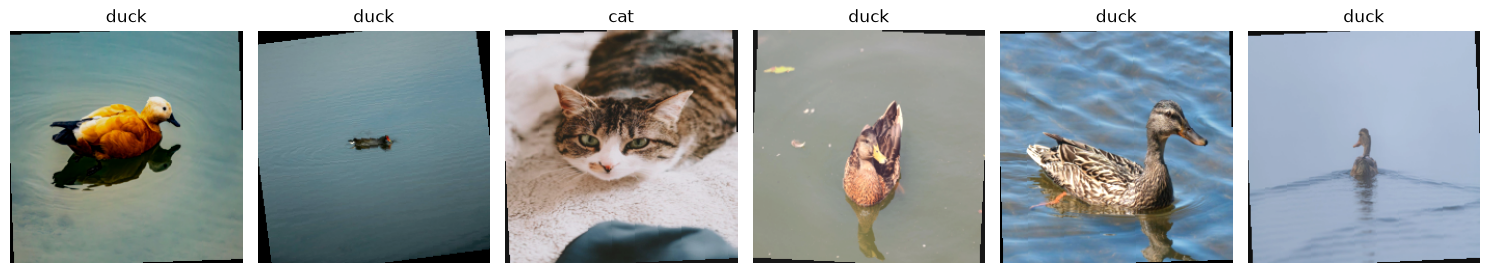

In [4]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(idx_to_class[labels[i].item()])
    ax.axis("off")
plt.tight_layout()

## Build the model

ResNet18 pretrained on ImageNet, with the final layer swapped for a 2-class head.

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_to_idx))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Train

In [6]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += inputs.size(0)
    return total_loss / total, correct / total

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_path = os.path.join(MODELS_DIR, "model.pt")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch}/{EPOCHS} — "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

print(f"Best val accuracy: {best_val_acc:.4f} (saved to {best_model_path})")

Epoch 1/10 — train_loss=0.4503 train_acc=0.7748 val_loss=0.0990 val_acc=0.9565
Epoch 2/10 — train_loss=0.0760 train_acc=0.9910 val_loss=0.0322 val_acc=1.0000
Epoch 3/10 — train_loss=0.0353 train_acc=0.9910 val_loss=0.0143 val_acc=1.0000
Epoch 4/10 — train_loss=0.0153 train_acc=1.0000 val_loss=0.0071 val_acc=1.0000
Epoch 5/10 — train_loss=0.0034 train_acc=1.0000 val_loss=0.0065 val_acc=1.0000
Epoch 6/10 — train_loss=0.0020 train_acc=1.0000 val_loss=0.0072 val_acc=1.0000
Epoch 7/10 — train_loss=0.0026 train_acc=1.0000 val_loss=0.0084 val_acc=1.0000
Epoch 8/10 — train_loss=0.0125 train_acc=1.0000 val_loss=0.0068 val_acc=1.0000
Epoch 9/10 — train_loss=0.0010 train_acc=1.0000 val_loss=0.0069 val_acc=1.0000
Epoch 10/10 — train_loss=0.0008 train_acc=1.0000 val_loss=0.0054 val_acc=1.0000
Best val accuracy: 1.0000 (saved to ../models\model.pt)


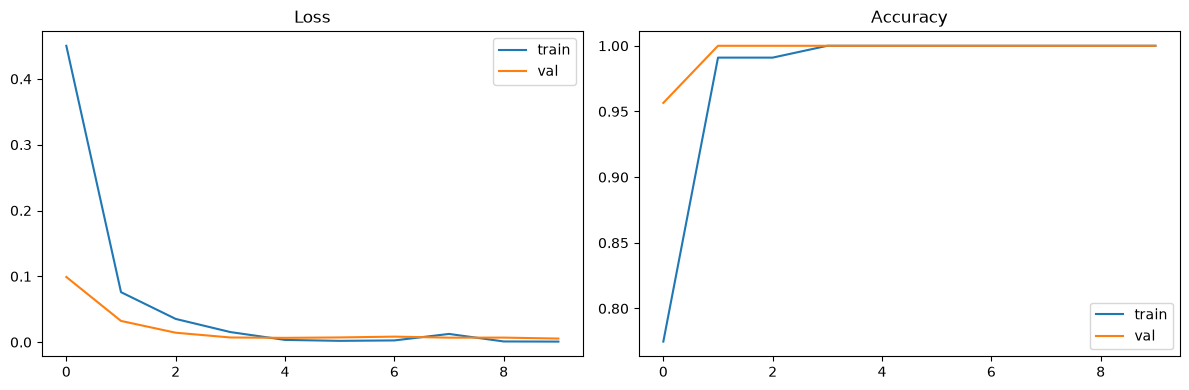

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()

## Evaluate on the held-out test set

Loads the best checkpoint (by validation accuracy) before scoring.

In [8]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(all_labels, all_preds, target_names=target_names))
print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

         cat       1.00      1.00      1.00         9
        duck       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

Confusion matrix:
[[ 9  0]
 [ 0 14]]


## Export the class mapping for the Flask app

In [9]:
classes_path = os.path.join(MODELS_DIR, "classes.json")
with open(classes_path, "w") as f:
    json.dump(idx_to_class, f, indent=2)

print(f"Model:   {best_model_path}")
print(f"Classes: {classes_path} -> {idx_to_class}")

Model:   ../models\model.pt
Classes: ../models\classes.json -> {0: 'cat', 1: 'duck'}
